In [1]:
import os
import pickle
from forge_class_instance3 import FORGE as forge_optuna

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_absolute_error
from matplotlib import rcParams

# === 0. Plot Settings (Matches your reference) ===
rcParams['pdf.fonttype'] = 42 
rcParams['ps.fonttype'] = 42   
rcParams['font.family'] = 'DejaVu Sans'

In [2]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"
dep_data = pd.read_csv(dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T

In [3]:
joint_model_path = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/DABRAFENIB_BRAF_forgeModel_optuna100.pkl'

In [4]:
joint_model = forge_optuna.load_forge(path = joint_model_path)

In [5]:
exp_data = pd.read_csv(joint_model.exp_path, header = 0, index_col = 0)

In [6]:
with open(joint_model_path, 'rb') as f:
        joint_model_i = pickle.load(f)

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [16]:
# === Gene Influence Calculation with L2 scaling ===
def calculate_scaled_gene_influence(W, h_D, h_I, gene_names):
    # L2 normalization
    h_D_norm = h_D / np.linalg.norm(h_D)
    h_I_norm = h_I / np.linalg.norm(h_I)

    # Influence calculation
    ic50_effect = -W @ h_I_norm
    dependency_effect = W @ h_D_norm
    total_influence = dependency_effect + ic50_effect  # or W @ (h_D_norm - h_I_norm)

    influence_df = pd.DataFrame({
        "Gene": gene_names,
        "IC50Effect": ic50_effect.ravel(),
        "DependencyEffect": dependency_effect.ravel(),
        "TotalInfluence": total_influence.ravel()
    }).set_index("Gene")

    return influence_df

# === Call the function ===
influence_df = calculate_scaled_gene_influence(joint_model_i.W, joint_model_i.hD, joint_model_i.hI, joint_model_i.hcg_list)


In [17]:
influence_df

,IC50Effect,DependencyEffect,TotalInfluence
Gene,,,
MYBL1,-0.526136,-0.059584,-0.585720
UBL7-DT,0.193163,-0.117613,0.075550
AK5,-0.765622,0.415748,-0.349873
REPS1,0.749249,-0.035611,0.713637
GGN,-0.825723,-0.467909,-1.293633
...,...,...,...
ITGB4,0.787276,-1.206158,-0.418882
HS3ST1,-0.262048,1.364993,1.102945
TMEM115,-1.287812,1.273835,-0.013978


In [18]:
# Assuming your DataFrame is called df and has index as gene names
# and columns: 'IC50Effect', 'DependencyEffect', 'TotalInfluence'

# Sort by TotalInfluence
df_sorted = influence_df.sort_values(by='TotalInfluence', ascending=False)

# Get top and bottom 20 gene names
top_20_genes = df_sorted.head(20).index.tolist()
bottom_20_genes = df_sorted.tail(20).index.tolist()

# Concatenate the lists
concatenated_gene_list = top_20_genes + bottom_20_genes

# Save to a .txt file
with open("Gene_imp_40_optuna.txt", "w") as f:
    for gene in concatenated_gene_list:
        f.write(f"{gene}\n")

In [4]:
Dabrafenib_pathway = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code/Suppl_figs/Enrichr-KG_Dabrafenib.csv")

In [6]:
top_pathways

,Term,Library,p-value,q-value,z-score,combined score,overlaps,-log10_qvalue
4,cell-cell adhesion (GO),GO_Biological_Process_2021,0.001637,0.11780,37.47,240.3,ITGAV;PARVA,0.928855
3,cell projection org. (GO),GO_Biological_Process_2021,0.001637,0.11780,37.47,240.3,GSN;PARVA,0.928855
12,Osteopontin Sig. WP,WikiPathway_2021_Human,0.025700,0.15400,42.62,156.1,ITGAV,0.812479
11,MAPK & NFkB sig. inhib. WP,WikiPathway_2021_Human,0.023740,0.15400,46.50,173.9,RRAS,0.812479
2,cell projection assembly (GO),GO_Biological_Process_2021,0.000878,0.11780,52.47,369.3,GSN;PARVA,0.928855
10,Degrad. pathway of sphingolipids WP,WikiPathway_2021_Human,0.019830,0.15400,56.84,222.9,GLB1,0.812479
8,Cytoskeletal Remodel. & Cell Spread.,Reactome_2022,0.015890,0.26030,73.09,302.7,PARVA,0.584526
9,Inhib. Of Cell Attachment & Migration,Reactome_2022,0.015890,0.26030,73.09,302.7,RRAS,0.584526
7,Cross-presentation Of Phagosomes,Reactome_2022,0.015890,0.26030,73.09,302.7,ITGAV,0.584526
0,Actin-med. cell contraction (GO),GO_Biological_Process_2021,0.000139,0.05998,150.00,1332.0,GSN;PARVA,1.221994


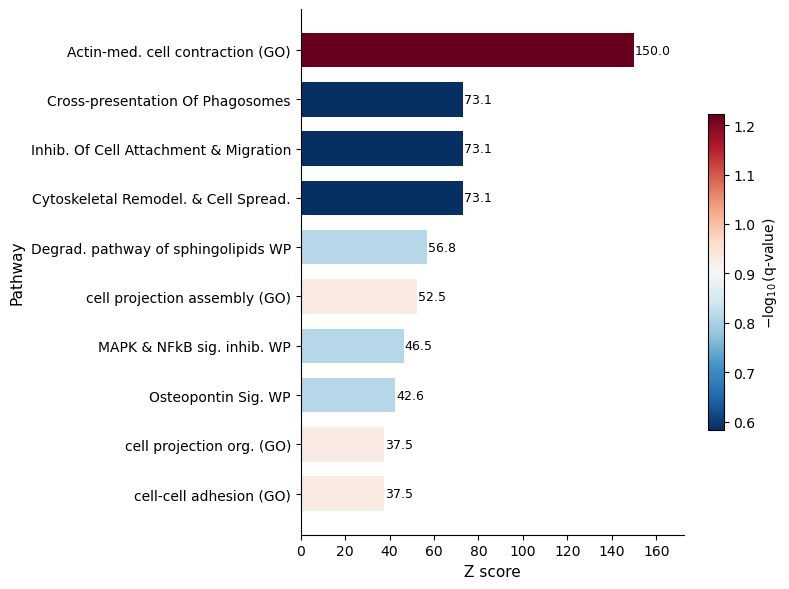

In [5]:
# Select top pathways and prepare data
# Sort by z-score and select top 10
top_pathways = Dabrafenib_pathway.nlargest(10, 'z-score').copy()

# Calculate -log10(q-value)
top_pathways['-log10_qvalue'] = -np.log10(top_pathways['q-value'])

# Sort by z-score for plotting (ascending so highest appears at top)
top_pathways = top_pathways.sort_values('z-score', ascending=True)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create colormap normalization
norm = plt.Normalize(vmin=top_pathways['-log10_qvalue'].min(), 
                     vmax=top_pathways['-log10_qvalue'].max())
#norm = plt.Normalize(vmin=0, vmax=1.2)  # example fixed scale


cmap = plt.cm.RdBu_r  # Red-Blue reversed (blue=low, red=high)

# Get colors for each bar based on -log10(q-value)
colors = cmap(norm(top_pathways['-log10_qvalue'].values))

# Create horizontal bar plot
bars = ax.barh(y=range(len(top_pathways)), 
               width=top_pathways['z-score'].values,
               color=colors,
               edgecolor='none',
               height=0.7)

# Set y-tick labels (pathway names)
# Clean up pathway names by removing extra info in parentheses if too long
pathway_labels = top_pathways['Term'].values
ax.set_yticks(range(len(top_pathways)))
ax.set_yticklabels(pathway_labels, fontsize=10)

# Add value labels at the end of each bar
for i, (bar, val) in enumerate(zip(bars, top_pathways['z-score'].values)):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}', va='center', ha='left', fontsize=9)

# Set labels
ax.set_xlabel('Z score', fontsize=11)
ax.set_ylabel('Pathway', fontsize=11)

# Set x-axis limits to accommodate labels
ax.set_xlim(0, top_pathways['z-score'].max() * 1.15)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, aspect=20)
cbar.set_label(r'$-\log_{10}$(q-value)', fontsize=10)

plt.tight_layout()
#plt.savefig('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Dabrafenib_pathway_barplot.pdf', 
#            dpi=300, bbox_inches='tight')
plt.show()